### Script de Convolución de Imagen

Este script cargará una imagen, te pedirá que definas un kernel de convolución de 3x3 y luego aplicará ese kernel a la imagen. Finalmente, mostrará la imagen original y la imagen filtrada lado a lado.

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
from skimage import data # Importado para usar imágenes de ejemplo
from skimage.measure import block_reduce # Importado para Max Pooling

In [46]:
# Cargar una imagen RGB de ejemplo
# Puedes cambiar esta URL por la ruta a tu propia imagen local si lo prefieres.
try:
    # Carga una imagen de ejemplo de scikit-image
    img_original_rgb = data.coffee()
    # OpenCV trabaja con BGR por defecto, matplotlib y skimage con RGB.
    # Convertimos a BGR para las operaciones de OpenCV.
    img_original = cv2.cvtColor(img_original_rgb, cv2.COLOR_RGB2BGR)
    print("Imagen 'coffee' cargada correctamente.")
except Exception as e:
    print(f"Error al cargar la imagen de ejemplo: {e}")
    print("Asegúrate de que la librería skimage está instalada y la imagen está disponible.")
    img_original_rgb = None
    img_original = None

Imagen 'coffee' cargada correctamente.


In [48]:
if img_original_rgb is not None:
    # Solicitar al usuario que ingrese el kernel 3x3
    print("Por favor, ingresa los 9 valores del kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo para un kernel de desenfoque simple: 1 1 1 1 1 1 1 1 1")

    while True:
        try:
            kernel_input_str = input("Valores del kernel (9 números): ")
            kernel_values = list(map(float, kernel_input_str.split()))

            if len(kernel_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                # Convertir la lista de valores a un array de NumPy y darle forma de 3x3
                kernel = np.array(kernel_values).reshape(3, 3)
                print("Kernel ingresado:")
                print(kernel)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")
else:
    print("No se pudo definir el kernel porque no se cargó ninguna imagen.")

Por favor, ingresa los 9 valores del kernel 3x3 (fila por fila), separados por espacios:
Ejemplo para un kernel de desenfoque simple: 1 1 1 1 1 1 1 1 1
Valores del kernel (9 números): 1 1 1 1 1 1 1 1 1
Kernel ingresado:
[[          1           1           1]
 [          1           1           1]
 [          1           1           1]]


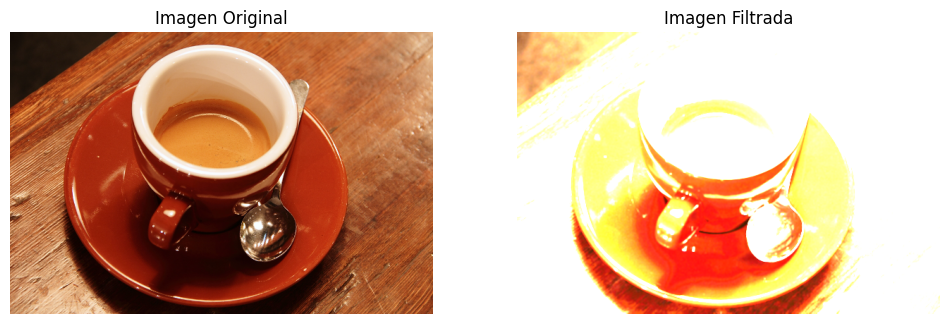

In [49]:
if img_original_rgb is not None and 'kernel' in locals():
    # Aplicar la convolución
    # cv2.filter2D requiere una imagen en BGR, así que volvemos a convertir si es necesario
    img_filtered = cv2.filter2D(img_original, -1, kernel)

    # Convertir la imagen filtrada a RGB para matplotlib
    img_filtered_rgb = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen original y la filtrada en un subplot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_original_rgb)
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_filtered_rgb)
    plt.title('Imagen Filtrada')
    plt.axis('off')

    plt.show()
else:
    print("No se pudo aplicar la convolución. Asegúrate de que la imagen se cargó y el kernel se definió correctamente.")

### Ejercicio 2: Doble Convolución

En este ejercicio, aplicaremos dos convoluciones con kernels diferentes a la misma imagen para observar el efecto de múltiples filtros.

In [50]:
if img_original_rgb is not None:
    print("\n--- Primer Kernel ---")
    print("Por favor, ingresa los 9 valores del PRIMER kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo para detección de bordes (Laplaciano): 0 1 0 1 -4 1 0 1 0")

    while True:
        try:
            kernel1_input_str = input("Valores del PRIMER kernel (9 números): ")
            kernel1_values = list(map(float, kernel1_input_str.split()))

            if len(kernel1_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                kernel1 = np.array(kernel1_values).reshape(3, 3)
                print("Primer Kernel ingresado:")
                print(kernel1)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")

    print("\n--- Segundo Kernel ---")
    print("Por favor, ingresa los 9 valores del SEGUNDO kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo para desenfoque (media): 1 1 1 1 1 1 1 1 1")

    while True:
        try:
            kernel2_input_str = input("Valores del SEGUNDO kernel (9 números): ")
            kernel2_values = list(map(float, kernel2_input_str.split()))

            if len(kernel2_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                kernel2 = np.array(kernel2_values).reshape(3, 3)
                print("Segundo Kernel ingresado:")
                print(kernel2)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")
else:
    print("No se pudieron definir los kernels porque no se cargó ninguna imagen.")


--- Primer Kernel ---
Por favor, ingresa los 9 valores del PRIMER kernel 3x3 (fila por fila), separados por espacios:
Ejemplo para detección de bordes (Laplaciano): 0 1 0 1 -4 1 0 1 0
Valores del PRIMER kernel (9 números): 0 -1 0 -1 5 -1 0 -1 0
Primer Kernel ingresado:
[[          0          -1           0]
 [         -1           5          -1]
 [          0          -1           0]]

--- Segundo Kernel ---
Por favor, ingresa los 9 valores del SEGUNDO kernel 3x3 (fila por fila), separados por espacios:
Ejemplo para desenfoque (media): 1 1 1 1 1 1 1 1 1
Valores del SEGUNDO kernel (9 números): -1 -1 -1 -1 8 -1 -1 -1 -1
Segundo Kernel ingresado:
[[         -1          -1          -1]
 [         -1           8          -1]
 [         -1          -1          -1]]


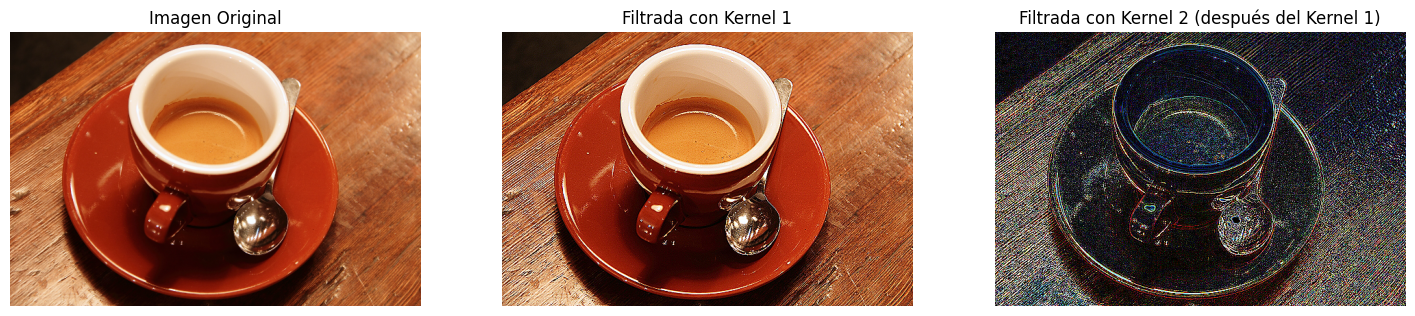

In [51]:
if img_original_rgb is not None and 'kernel1' in locals() and 'kernel2' in locals():
    # Aplicar la primera convolución
    img_filtered1 = cv2.filter2D(img_original, -1, kernel1)

    # Aplicar la segunda convolución sobre el resultado de la primera
    img_filtered2 = cv2.filter2D(img_filtered1, -1, kernel2)

    # Convertir las imágenes filtradas a RGB para matplotlib
    img_filtered1_rgb = cv2.cvtColor(img_filtered1, cv2.COLOR_BGR2RGB)
    img_filtered2_rgb = cv2.cvtColor(img_filtered2, cv2.COLOR_BGR2RGB)

    # Mostrar las tres imágenes en un subplot
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original_rgb)
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_filtered1_rgb)
    plt.title('Filtrada con Kernel 1')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_filtered2_rgb)
    plt.title('Filtrada con Kernel 2 (después del Kernel 1)')
    plt.axis('off')

    plt.show()
else:
    print("No se pudieron aplicar las convoluciones. Asegúrate de que la imagen se cargó y ambos kernels se definieron correctamente.")

### Ejercicio 3: Convoluciones, ReLU y Max Pooling

En este ejercicio, simularemos una parte de una red neuronal convolucional aplicando tres convoluciones secuenciales, cada una seguida de una función de activación ReLU, y finalmente una operación de Max Pooling.

In [52]:
if img_original_rgb is not None:
    print("\n--- Primer Kernel (Convolución 1) ---")
    print("Por favor, ingresa los 9 valores del PRIMER kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo (detección de bordes): -1 -1 -1 -1 8 -1 -1 -1 -1")

    while True:
        try:
            kernel3_input_str = input("Valores del PRIMER kernel (9 números): ")
            kernel3_values = list(map(float, kernel3_input_str.split()))
            if len(kernel3_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                kernel3 = np.array(kernel3_values).reshape(3, 3)
                print("Primer Kernel ingresado:")
                print(kernel3)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")

    print("\n--- Segundo Kernel (Convolución 2) ---")
    print("Por favor, ingresa los 9 valores del SEGUNDO kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo (suavizado): 1 1 1 1 1 1 1 1 1")

    while True:
        try:
            kernel4_input_str = input("Valores del SEGUNDO kernel (9 números): ")
            kernel4_values = list(map(float, kernel4_input_str.split()))
            if len(kernel4_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                kernel4 = np.array(kernel4_values).reshape(3, 3)
                print("Segundo Kernel ingresado:")
                print(kernel4)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")

    print("\n--- Tercer Kernel (Convolución 3) ---")
    print("Por favor, ingresa los 9 valores del TERCER kernel 3x3 (fila por fila), separados por espacios:")
    print("Ejemplo (realce de bordes): 0 -1 0 -1 5 -1 0 -1 0")

    while True:
        try:
            kernel5_input_str = input("Valores del TERCER kernel (9 números): ")
            kernel5_values = list(map(float, kernel5_input_str.split()))
            if len(kernel5_values) != 9:
                print("Debes ingresar exactamente 9 valores. Inténtalo de nuevo.")
            else:
                kernel5 = np.array(kernel5_values).reshape(3, 3)
                print("Tercer Kernel ingresado:")
                print(kernel5)
                break
        except ValueError:
            print("Entrada no válida. Asegúrate de ingresar solo números separados por espacios. Inténtalo de nuevo.")
else:
    print("No se pudieron definir los kernels porque no se cargó ninguna imagen.")


--- Primer Kernel (Convolución 1) ---
Por favor, ingresa los 9 valores del PRIMER kernel 3x3 (fila por fila), separados por espacios:
Ejemplo (detección de bordes): -1 -1 -1 -1 8 -1 -1 -1 -1
Valores del PRIMER kernel (9 números): 0 -1 0 -1 5 -1 0 -1 0
Primer Kernel ingresado:
[[          0          -1           0]
 [         -1           5          -1]
 [          0          -1           0]]

--- Segundo Kernel (Convolución 2) ---
Por favor, ingresa los 9 valores del SEGUNDO kernel 3x3 (fila por fila), separados por espacios:
Ejemplo (suavizado): 1 1 1 1 1 1 1 1 1
Valores del SEGUNDO kernel (9 números): -1 -1 -1 -1 8 -1 -1 -1 -1
Segundo Kernel ingresado:
[[         -1          -1          -1]
 [         -1           8          -1]
 [         -1          -1          -1]]

--- Tercer Kernel (Convolución 3) ---
Por favor, ingresa los 9 valores del TERCER kernel 3x3 (fila por fila), separados por espacios:
Ejemplo (realce de bordes): 0 -1 0 -1 5 -1 0 -1 0
Valores del TERCER kernel (9 núme

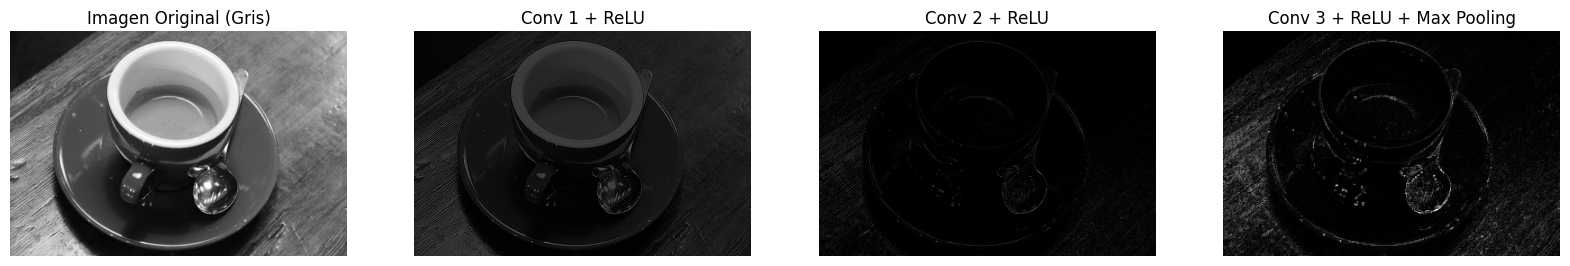

In [53]:
if img_original_rgb is not None and 'kernel3' in locals() and 'kernel4' in locals() and 'kernel5' in locals():
    # Convertir la imagen a escala de grises para simplificar los mapas de características
    img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

    # Función ReLU
    def relu(x):
        return np.maximum(0, x)

    # --- Etapa 1: Convolución 1 + ReLU ---
    # Usar cv2.CV_32F para el ddepth para evitar la saturación de los valores
    conv1 = cv2.filter2D(img_gray, cv2.CV_32F, kernel3)
    output1 = relu(conv1)

    # --- Etapa 2: Convolución 2 + ReLU ---
    conv2 = cv2.filter2D(output1, cv2.CV_32F, kernel4)
    output2 = relu(conv2)

    # --- Etapa 3: Convolución 3 + ReLU ---
    conv3 = cv2.filter2D(output2, cv2.CV_32F, kernel5)
    output3 = relu(conv3)

    # --- Etapa 4: Max Pooling 2x2 ---
    # Asegurarse de que las dimensiones sean pares para el pooling, rellenar si es necesario
    h, w = output3.shape
    h_padded = h + (h % 2)
    w_padded = w + (w % 2)
    output3_padded = np.pad(output3, ((0, h_padded - h), (0, w_padded - w)), mode='constant')
    max_pool_output = block_reduce(output3_padded, block_size=(2, 2), func=np.max)

    # Mostrar los mapas de características resultantes
    plt.figure(figsize=(20, 8))

    plt.subplot(1, 4, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Imagen Original (Gris)')
    plt.axis('off')

    # Para visualizar correctamente los mapas de características flotantes, normalizaremos
    # los valores de cada output al rango de 0-1 o 0-255 para la visualización.
    # Usamos vmin y vmax para asegurar que la visualización abarque todo el rango dinámico de cada output.
    plt.subplot(1, 4, 2)
    plt.imshow(output1, cmap='gray', vmin=output1.min(), vmax=output1.max())
    plt.title('Conv 1 + ReLU')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(output2, cmap='gray', vmin=output2.min(), vmax=output2.max())
    plt.title('Conv 2 + ReLU')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(max_pool_output, cmap='gray', vmin=max_pool_output.min(), vmax=max_pool_output.max())
    plt.title('Conv 3 + ReLU + Max Pooling')
    plt.axis('off')

    plt.show()
else:
    print("No se pudieron aplicar las convoluciones y el pooling. Asegúrate de que la imagen se cargó y los tres kernels se definieron correctamente.")

### Ejercicio 4: Segmentación de Imagen con YOLOv8

En este ejercicio, utilizaremos un modelo preentrenado de YOLOv8 para realizar la segmentación de instancias en una imagen. El modelo detectará objetos y generará máscaras para cada uno de ellos, permitiéndonos ver dónde se encuentra cada objeto en la imagen.

In [54]:
# Instalar la librería ultralytics para YOLOv8
%pip install ultralytics


0: 448x640 1 cup, 1 dining table, 708.9ms
Speed: 9.0ms preprocess, 708.9ms inference, 21.0ms postprocess per image at shape (1, 3, 448, 640)


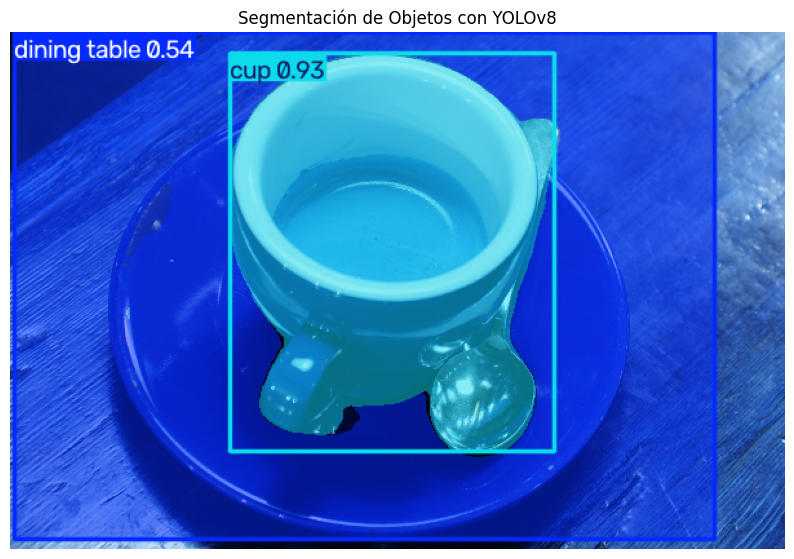

Segmentación completada. Se muestran las máscaras de los objetos detectados.


In [55]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import cv2

if img_original_rgb is not None:
    # Cargar el modelo YOLOv8 de segmentación preentrenado
    # Puedes elegir entre 'yolov8n-seg.pt', 'yolov8s-seg.pt', etc.
    # 'n' es nano (más pequeño y rápido), 's' es small.
    model = YOLO('yolov8n-seg.pt')  # Carga el modelo nano de segmentación

    # Realizar inferencia en la imagen original
    # `img_original_rgb` ya está en formato RGB, que es el esperado por YOLO.
    results = model(img_original_rgb)

    # Mostrar los resultados de la segmentación
    # La función `plot()` de los resultados ya dibuja las cajas y máscaras.
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        # Convertir de BGR a RGB para mostrar con matplotlib
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb)
        plt.title('Segmentación de Objetos con YOLOv8')
        plt.axis('off')
        plt.show()

    print("Segmentación completada. Se muestran las máscaras de los objetos detectados.")
else:
    print("No se pudo realizar la segmentación porque no se cargó ninguna imagen.")

### Ejercicio 5: Segmentación de Imagen con YOLOv8 y Esquema de Fine-tuning

En este ejercicio, cargaremos una imagen de un animal y exploraremos el concepto de *fine-tuning* para mejorar la segmentación con YOLOv8. El *fine-tuning* permite adaptar un modelo preentrenado a un conjunto de datos específico para mejorar su rendimiento en tareas particulares.

Imagen cargada correctamente para el Ejercicio 5.


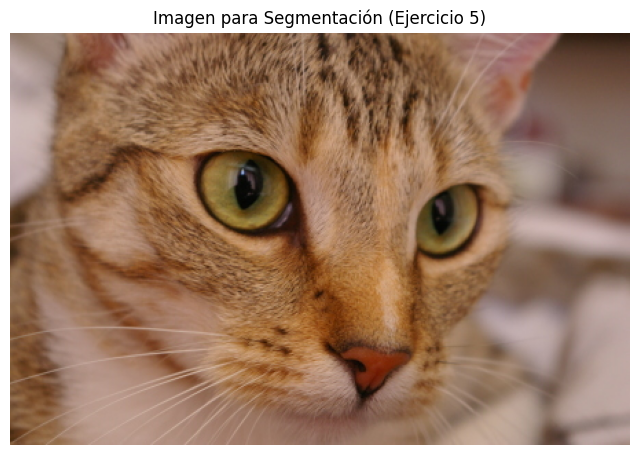

In [59]:
import cv2
import matplotlib.pyplot as plt
from skimage import io # Importar io para leer imágenes

# Cargar una imagen de un animal para el Ejercicio 5
try:
    # POR FAVOR, REEMPLAZA '/content/mi_imagen_animales.jpg' CON LA RUTA DE TU IMAGEN SUBIDA
    # Puedes subir una imagen con múltiples animales a tu entorno de Colab.
    # Ejemplo: img_animal_rgb = io.imread('/content/mi_imagen_animales.jpg')
    # Usaremos una imagen de ejemplo de scikit-image si no se especifica una ruta.
    # Si la imagen subida es BGR, conviértela a RGB con cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Si subes tu propia imagen, descomenta la línea de abajo y ajusta la ruta:
    # img_animal_rgb = io.imread('/content/mi_imagen_con_varios_animales.jpg')
    # O usa una imagen de ejemplo incorporada si no tienes una para subir:
    from skimage import data
    img_animal_rgb = data.chelsea() # Usamos 'chelsea' (un gato) como ejemplo por defecto

    print("Imagen cargada correctamente para el Ejercicio 5.")

    plt.figure(figsize=(8, 8))
    plt.imshow(img_animal_rgb)
    plt.title('Imagen para Segmentación (Ejercicio 5)')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print("Error: No se encontró la imagen en la ruta especificada. Asegúrate de haberla subido y de que la ruta es correcta.")
    img_animal_rgb = None
except Exception as e:
    print(f"Error al cargar la imagen: {e}")
    print("Asegúrate de que la librería `skimage` está instalada y la imagen está disponible y en un formato compatible.")
    img_animal_rgb = None

#### Esquema de Fine-tuning para YOLOv8

El *fine-tuning* de un modelo YOLOv8 implica tomar un modelo preentrenado (como `yolov8n-seg.pt`) y entrenarlo adicionalmente con un **conjunto de datos personalizado**. Esto es útil cuando los objetos que quieres segmentar no están bien representados en el conjunto de datos original con el que se entrenó el modelo, o cuando necesitas una mayor precisión para clases específicas.

**Pasos clave para el Fine-tuning:**
1.  **Preparar el Conjunto de Datos:** Necesitas imágenes y sus correspondientes anotaciones de segmentación (máscaras) en un formato compatible con YOLO (por ejemplo, COCO, YOLOv5 o un formato personalizado descrito en un archivo YAML).
2.  **Configurar el Archivo YAML:** Crear un archivo YAML que describa la ubicación de tus imágenes de entrenamiento/validación y la lista de nombres de tus clases personalizadas.
3.  **Cargar el Modelo Preentrenado:** Instanciar el modelo YOLOv8 que deseas ajustar (e.g., `model = YOLO('yolov8n-seg.pt')`).
4.  **Entrenar el Modelo:** Ejecutar el método `train()` del modelo, especificando el archivo YAML de datos, el número de épocas, el tamaño de la imagen, etc.

```python
# Ejemplo conceptual de cómo iniciar el fine-tuning:
# model = YOLO('yolov8n-seg.pt') # Cargar el modelo base
# model.train(data='path/to/your/dataset.yaml', epochs=50, imgsz=640)
# (Esto requeriría un conjunto de datos real y un tiempo de entrenamiento considerable)
```

Dado que no tenemos un conjunto de datos personalizado etiquetado para animales en este entorno, no realizaremos un entrenamiento real. Sin embargo, para demostrar la segmentación en la imagen de animal, usaremos el modelo YOLOv8 preentrenado estándar.

Realizando segmentación en la imagen del animal con el modelo YOLOv8 base...

0: 448x640 1 cat, 1 zebra, 199.6ms
Speed: 7.8ms preprocess, 199.6ms inference, 4.9ms postprocess per image at shape (1, 3, 448, 640)


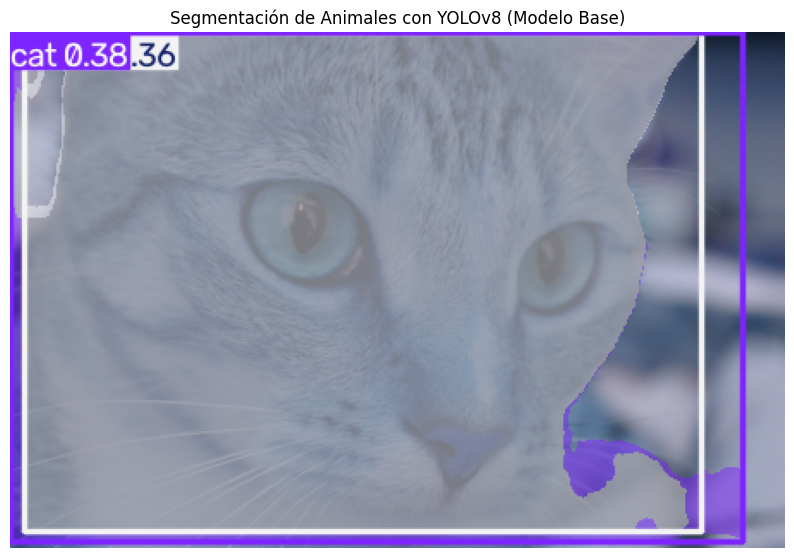

Segmentación completada. Se muestran las máscaras de los objetos detectados en la imagen del animal.


In [60]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import cv2

if 'img_animal_rgb' in locals() and img_animal_rgb is not None:
    # Cargar el modelo YOLOv8 de segmentación preentrenado (mismo que en Ejercicio 4)
    model_seg = YOLO('yolov8n-seg.pt')

    print("Realizando segmentación en la imagen del animal con el modelo YOLOv8 base...")
    # Realizar inferencia en la imagen del animal
    results_animal = model_seg(img_animal_rgb)

    # Mostrar los resultados de la segmentación
    for r in results_animal:
        im_array_animal = r.plot()  # plot a BGR numpy array of predictions
        # Convertir de BGR a RGB para mostrar con matplotlib
        im_rgb_animal = cv2.cvtColor(im_array_animal, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb_animal)
        plt.title('Segmentación de Animales con YOLOv8 (Modelo Base)')
        plt.axis('off')
        plt.show()

    print("Segmentación completada. Se muestran las máscaras de los objetos detectados en la imagen del animal.")
else:
    print("No se pudo realizar la segmentación porque la imagen de animal no se cargó correctamente.")

### Ejercicio 6: Detección de Objetos en Video con YOLOv8

En este ejercicio, aplicaremos el modelo de detección de objetos YOLOv8 a un video. Leeremos el video frame a frame, realizaremos la detección en cada uno y mostraremos los resultados.

In [63]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode

# --- 1. Cargar el Video ---
# Se usará un video de ejemplo desde una URL pública.
# Si deseas usar tu propio video, sube el archivo a Colab y reemplaza esta URL con la ruta local (e.g., '/content/tu_video.mp4')
video_path = 'https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: No se pudo abrir el archivo de video en la ruta: {video_path}")
    print("Asegúrate de que el archivo existe y la ruta es correcta. Si es un URL, verifica que es un enlace directo al video.")
    video_loaded = False
else:
    print(f"Video cargado correctamente desde: {video_path}")
    # Obtener propiedades del video
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Dimensiones: {frame_width}x{frame_height}, FPS: {fps:.2f}, Frames: {total_frames}")
    video_loaded = True

# --- 2. Cargar el modelo YOLOv8 de Detección ---
if video_loaded:
    print("Cargando el modelo YOLOv8 de detección...")
    model_detection = YOLO('yolov8n.pt') # Modelo nano de detección
    print("Modelo YOLOv8 de detección cargado.")
else:
    print("No se pudo cargar el modelo YOLOv8 de detección sin un video válido.")

Video cargado correctamente desde: https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4
Dimensiones: 320x240, FPS: 15.00, Frames: 1889
Cargando el modelo YOLOv8 de detección...
Modelo YOLOv8 de detección cargado.


In [64]:
if video_loaded:
    print("Procesando video y realizando detección de objetos. Esto puede tardar unos minutos...")

    # Configurar el escritor de video para guardar los resultados
    output_video_path = '/content/output_video_yolo.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec para .mp4
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Realizar detección en el frame
        results = model_detection(frame, verbose=False) # verbose=False para no imprimir cada resultado en la consola

        # Dibujar las detecciones en el frame
        annotated_frame = results[0].plot() # YOLO's plot() method returns a BGR numpy array

        # Escribir el frame anotado en el video de salida
        out.write(annotated_frame)

        frame_count += 1
        if frame_count % 100 == 0: # Imprimir progreso cada 100 frames
            print(f"Frames procesados: {frame_count}/{total_frames}")

    cap.release()
    out.release()
    print("Procesamiento de video completado. Video guardado en '/content/output_video_yolo.mp4'")

    # --- Mostrar el Video Procesado en Colab (método HTML5) ---
    # Es más eficiente y fiable que intentar mostrarlo en tiempo real.
    try:
        mp4 = open(output_video_path, 'rb').read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
        display(HTML(f"""
        <video width="{frame_width}" height="{frame_height}" controls>
            <source src="{data_url}" type="video/mp4">
        </video>"""))
        print("Video con detecciones mostrado arriba. También puedes descargarlo desde '/content/output_video_yolo.mp4'.")
    except FileNotFoundError:
        print("Error: No se encontró el video de salida para mostrarlo.")
    except Exception as e:
        print(f"Error al mostrar el video: {e}")

else:
    print("No se pudo procesar el video para detección de objetos.")

Output hidden; open in https://colab.research.google.com to view.

Falta el fine tunning.